# Proyek Klasifikasi Gambar: Food-41 Dataset
- **Nama:** Alif Nurhidayat
- **Email:** alifnurhidayatwork@gmail.com, mc189d5y0351@student.devacademy.id
- **ID Dicoding:** MC189D5Y0351

**Ringkasan:**  
- Download dataset Food‐41 via Kaggle API  
- Split dataset → train/val/test (70/15/15)  
- Data augmentation + preprocessing dengan `ImageDataGenerator`  
- Transfer learning: MobileNetV2 + top‐layers custom  
- Callbacks: EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, custom accuracy threshold  
- Evaluasi: akurasi ≥ 85%, plot loss/accuracy, confusion matrix, classification report  
- Export model:  
    1. SavedModel (folder `saved_model/`)  
    2. TFLite (file `model.tflite`)

## Import Semua Packages/Library yang Digunakan

In [ ]:
# Uninstall tensorflow
# %pip uninstall -y tensorflow

In [ ]:
%pip install --upgrade pip setuptools
!python -m pip install --upgrade pip setuptools

In [ ]:
# Instalasi dependensi (jalankan di Jupyter/Notebook satu kali)
%pip install Pillow
%pip install matplotlib pandas kagglehub ipywidgets
%pip install kagglehub[pandas-datasets]

In [ ]:
%pip install tensorflow tensorflowjs keras scikit-learn

In [ ]:
# Import Library
import os
import random
import shutil
import datetime
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint,
    ReduceLROnPlateau, TensorBoard, Callback
)
from tensorflow.keras.preprocessing import image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import itertools

import kagglehub
from kagglehub import KaggleDatasetAdapter

In [ ]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    # Print details of the detected GPU(s)
    for gpu in gpus:
      print("Detected GPU:", gpu)
      # Optional: Enable memory growth to avoid allocating all GPU memory at once
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    # Memory growth must be set before GPUs have been initialized
    print(e)
else:
    print("No GPU detected by TensorFlow.")

# Quick test operation
try:
    with tf.device('/GPU:0'): # Explicitly try to use the first GPU
        a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
        b = tf.constant([[1.0, 1.0], [0.0, 1.0]])
        c = tf.matmul(a, b)
    print("Matrix multiplication on GPU successful:", c.numpy())
except Exception as e:
    print("Could not run operation on GPU:", e)

print(tf.config.list_physical_devices('GPU'))

Num GPUs Available:  0
No GPU detected by TensorFlow.
Matrix multiplication on GPU successful: [[1. 3.]
 [3. 7.]]
[]


## Data Preparation

### Data Loading

Mencari dataset lokal di: 'datasets/food41'
Dataset lokal valid ditemukan di 'datasets/food41'. Menggunakan path ini.

Menggunakan dataset dari path final: datasets/food41

Menganalisis struktur direktori dataset di 'datasets/food41'...
Mencari direktori gambar di: 'datasets/food41/images'

Struktur direktori dataset 'datasets/food41':
['images', 'food_c101_n10099_r32x32x3.h5', 'food_test_c101_n1000_r64x64x3.h5', 'food_c101_n1000_r384x384x3.h5', 'food_test_c101_n1000_r128x128x3.h5', 'meta'] 

Konten direktori gambar 'datasets/food41/images':
['mussels', 'guacamole', 'pork_chop', 'prime_rib', 'beef_carpaccio', 'lobster_bisque', 'french_toast', 'baby_back_ribs', 'macarons'] 

Jumlah kategori makanan ditemukan: 9
Beberapa contoh kategori: ['baby_back_ribs', 'beef_carpaccio', 'french_toast', 'guacamole', 'lobster_bisque']

Menganalisis gambar di 'datasets/food41/images'...
Memproses 9 kategori...

Total gambar ditemukan: 8998
Jumlah kategori diproses: 9

5 kategori teratas berdasarkan juml

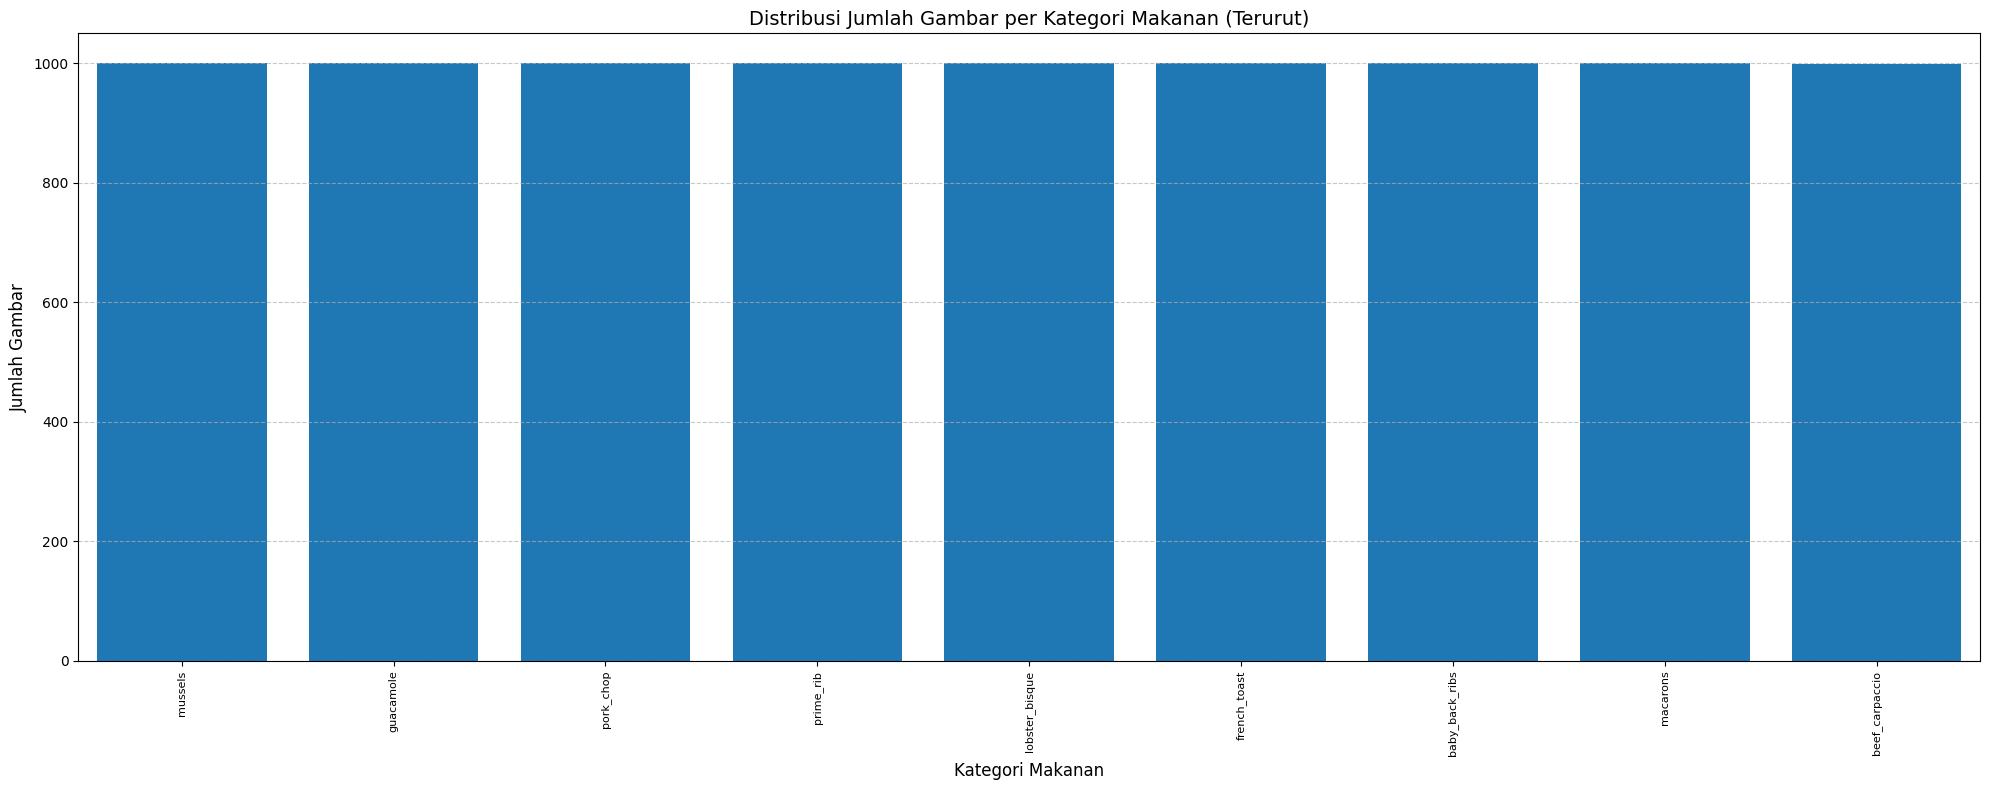

Visualisasi selesai.

Proses selesai.


In [ ]:
# --- Konfigurasi ---
DATASET_SLUG = "kmader/food41" # Slug dataset di Kaggle
LOCAL_DATA_ROOT = "datasets"  # Direktori root untuk menyimpan semua dataset lokal
IMAGE_SUBDIR = "images"     # Nama subdirektori berisi gambar

# --- Langkah 1: Tentukan dan Cek Path Lokal ---

# Buat nama direktori lokal yang spesifik untuk dataset ini
# Menggunakan bagian terakhir dari slug (lebih sederhana)
local_dataset_name = DATASET_SLUG.split('/')[-1]
# Alternatif: Menggunakan slug penuh (lebih aman jika ada nama sama)
# local_dataset_name = DATASET_SLUG.replace('/', '_')

# Path lengkap ke direktori dataset lokal yang diharapkan
expected_local_path = os.path.join(LOCAL_DATA_ROOT, local_dataset_name)
# Path lengkap ke direktori gambar di dalam lokasi lokal yang diharapkan
expected_local_images_path = os.path.join(expected_local_path, IMAGE_SUBDIR)

dataset_path = None # Akan diisi dengan path yang valid (lokal atau hasil unduh)

print(f"Mencari dataset lokal di: '{expected_local_path}'")

# Cek apakah direktori gambar lokal yang diharapkan ada dan valid
if os.path.isdir(expected_local_images_path):
    print(f"Dataset lokal valid ditemukan di '{expected_local_path}'. Menggunakan path ini.")
    dataset_path = expected_local_path
else:
    print(f"Dataset lokal tidak ditemukan atau tidak valid di '{expected_local_path}'.")
    print("Mencoba mengunduh/mendapatkan path dari KaggleHub...")

    # --- Langkah 2: Unduh atau Dapatkan Path dari KaggleHub (jika lokal tidak ada) ---
    try:
        # Minta path dari KaggleHub (mungkin mengunduh ke cache jika belum ada)
        downloaded_path = kagglehub.dataset_download(DATASET_SLUG)
        print(f"KaggleHub menyediakan path: {downloaded_path}")

        # Validasi path yang dikembalikan KaggleHub
        kaggle_images_path = os.path.join(downloaded_path, IMAGE_SUBDIR)
        if not os.path.isdir(kaggle_images_path):
             # Kasus khusus jika KaggleHub mengembalikan zip file (jarang untuk dataset ini tapi mungkin saja)
            if os.path.isfile(downloaded_path) and zipfile.is_zipfile(downloaded_path):
                 print(f"Error: KaggleHub mengembalikan file zip ('{downloaded_path}'), skrip ini mengharapkan direktori.")
                 print("Anda perlu menambahkan logika ekstraksi zip jika ini terjadi.")
                 # TODO: Tambahkan logika ekstraksi di sini jika perlu
                 exit()
            else:
                 print(f"Error: Path dari KaggleHub ('{downloaded_path}') tidak valid atau tidak berisi subdirektori '{IMAGE_SUBDIR}'.")
                 # Coba lihat isi downloaded_path
                 try:
                     print(f"Isi '{downloaded_path}': {os.listdir(downloaded_path)}")
                 except Exception as list_err:
                     print(f"Tidak bisa membaca isi '{downloaded_path}': {list_err}")
                 exit()

        # --- Langkah 2.5: Pindahkan dari Cache ke Lokasi Lokal Target ---
        print(f"\nMemindahkan dataset dari '{downloaded_path}' ke '{expected_local_path}'...")
        try:
            # Pastikan direktori root lokal ada
            os.makedirs(LOCAL_DATA_ROOT, exist_ok=True)

            # Hapus target jika sudah ada (misal dari run sebelumnya yang gagal)
            if os.path.exists(expected_local_path):
                print(f"Warning: Menghapus '{expected_local_path}' yang sudah ada sebelum memindahkan...")
                if os.path.isdir(expected_local_path):
                    shutil.rmtree(expected_local_path)
                else:
                    os.remove(expected_local_path)

            # Lakukan pemindahan
            shutil.move(downloaded_path, expected_local_path)
            print(f"Dataset berhasil dipindahkan ke '{expected_local_path}'.")
            dataset_path = expected_local_path # Gunakan path lokal setelah dipindahkan

        except Exception as move_err:
            print(f"Error saat memindahkan dataset ke lokasi lokal: {move_err}")
            print(f"Dataset mungkin masih ada di cache KaggleHub: '{downloaded_path}'.")
            print("Menggunakan path dari cache KaggleHub untuk sesi ini.")
            # Fallback: gunakan path asli dari kagglehub jika pemindahan gagal
            dataset_path = downloaded_path

    except Exception as e:
        print(f"Error saat mengunduh atau memproses dari KaggleHub: {e}")
        print("Pastikan slug dataset benar, koneksi internet stabil, dan autentikasi Kaggle benar.")
        exit() # Keluar jika unduhan/proses KaggleHub gagal

# --- Pemeriksaan Akhir ---
if dataset_path is None or not os.path.isdir(os.path.join(dataset_path, IMAGE_SUBDIR)):
    print("\nError: Tidak dapat menentukan path dataset yang valid.")
    exit()

print(f"\nMenggunakan dataset dari path final: {dataset_path}")

# --- Langkah 3: Menganalisis Struktur Dataset ---
# Kode di bawah ini sekarang menggunakan dataset_path yang sudah ditentukan
print(f"\nMenganalisis struktur direktori dataset di '{dataset_path}'...")

image_dir_path = os.path.join(dataset_path, IMAGE_SUBDIR)

print(f"Mencari direktori gambar di: '{image_dir_path}'") # Ini redundant, sudah dicek

# (Pemeriksaan keberadaan image_dir_path bisa dihapus karena sudah divalidasi sebelumnya)
# if not os.path.isdir(image_dir_path): ... (dihapus)

print(f"\nStruktur direktori dataset '{dataset_path}':")
try:
    root_contents = os.listdir(dataset_path)
    print(root_contents[:10], "..." if len(root_contents) > 10 else "")
except Exception as e:
    print(f"Gagal membaca isi '{dataset_path}': {e}")

print(f"\nKonten direktori gambar '{image_dir_path}':")
try:
    image_contents = os.listdir(image_dir_path)
    print(image_contents[:10], "..." if len(image_contents) > 10 else "")
except Exception as e:
      print(f"Gagal membaca isi '{image_dir_path}': {e}")
      exit() # Keluar jika tidak bisa membaca direktori gambar

# Mendapatkan daftar kategori
kategori_makanan = []
try:
    kategori_makanan = sorted([d for d in os.listdir(image_dir_path) if os.path.isdir(os.path.join(image_dir_path, d))])
    print(f"\nJumlah kategori makanan ditemukan: {len(kategori_makanan)}")
    if kategori_makanan:
        print("Beberapa contoh kategori:", kategori_makanan[:5])
    else:
        print(f"Tidak ada subdirektori (kategori) yang ditemukan di dalam '{image_dir_path}'.")
except Exception as e:
     print(f"Gagal membaca direktori kategori di '{image_dir_path}': {e}")
     # Tidak keluar, analisis gambar akan menangani list kosong

# --- Langkah 4: Mengecek Jumlah Gambar dan Resolusinya ---
# Fungsi analisis_gambar_dataset (tidak diubah isinya)
def analisis_gambar_dataset(direktori_gambar, ukuran_sampel=5):
    ukuran_unik = set()
    jumlah_kategori_dict = {}
    total_gambar = 0
    print(f"\nMenganalisis gambar di '{direktori_gambar}'...")
    if not os.path.isdir(direktori_gambar):
        print(f"Error: Direktori '{direktori_gambar}' tidak valid.")
        return 0, {}, set()
    try:
        list_kategori = [d for d in os.listdir(direktori_gambar) if os.path.isdir(os.path.join(direktori_gambar, d))]
    except Exception as e:
        print(f"Error saat listing kategori di '{direktori_gambar}': {e}")
        return 0, {}, set()
    if not list_kategori:
        print("Tidak ditemukan subdirektori kategori di dalam direktori gambar.")
        return 0, {}, set()
    print(f"Memproses {len(list_kategori)} kategori...")
    for kategori in list_kategori:
        jalur_kategori = os.path.join(direktori_gambar, kategori)
        try:
            if not os.path.isdir(jalur_kategori): continue
            file_gambar = [f for f in os.listdir(jalur_kategori) if os.path.isfile(os.path.join(jalur_kategori, f)) and f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            jumlah_gambar_kategori = len(file_gambar)
            jumlah_kategori_dict[kategori] = jumlah_gambar_kategori
            total_gambar += jumlah_gambar_kategori
            if jumlah_gambar_kategori > 0:
                sampel_actual_size = min(ukuran_sampel, jumlah_gambar_kategori)
                if sampel_actual_size > 0:
                    try: sampel_gambar = random.sample(file_gambar, sampel_actual_size)
                    except ValueError: continue
                    for file_img in sampel_gambar:
                        jalur_img = os.path.join(jalur_kategori, file_img)
                        try:
                            if os.path.isfile(jalur_img):
                                with Image.open(jalur_img) as img: ukuran_unik.add(img.size)
                        except FileNotFoundError: print(f"Warning: File gambar sampel {jalur_img} tidak ditemukan saat dibuka.")
                        except UnidentifiedImageError: print(f"Warning: Tidak dapat mengidentifikasi file gambar {jalur_img}.")
                        except Exception as e: print(f"Warning: Gagal membuka/memproses gambar {jalur_img}. Error: {e}")
        except Exception as e: print(f"Warning: Error saat memproses kategori {kategori}: {e}")
    print(f"\nTotal gambar ditemukan: {total_gambar}")
    print(f"Jumlah kategori diproses: {len(jumlah_kategori_dict)}")
    if jumlah_kategori_dict:
        kategori_terurut = sorted(jumlah_kategori_dict.items(), key=lambda item: item[1], reverse=True)
        print("\n5 kategori teratas berdasarkan jumlah gambar:")
        for kategori, jumlah in kategori_terurut[:5]: print(f"- {kategori}: {jumlah} gambar")
    print("\nResolusi gambar unik yang ditemukan dari sampel:")
    if ukuran_unik:
        for ukuran in sorted(list(ukuran_unik), key=lambda x: (x[0], x[1])): print(f"- {ukuran[0]}x{ukuran[1]}")
    else: print("- Tidak ada resolusi yang dapat dibaca dari sampel/tidak ada gambar.")
    return total_gambar, jumlah_kategori_dict, ukuran_unik

# Panggil fungsi analisis
# (Cek if image_dir_path/kategori_makanan valid bisa disederhanakan krn sudah ada cek di awal)
if kategori_makanan: # Cukup cek jika ada kategori yang ditemukan
    total_gambar, jumlah_kategori, ukuran_unik = analisis_gambar_dataset(image_dir_path, ukuran_sampel=5)
else:
    print("\nAnalisis gambar dilewati karena tidak ada kategori yang ditemukan.")
    total_gambar = 0
    jumlah_kategori = {}

# --- Langkah 5: Visualisasi Distribusi Gambar per Kategori ---
# (Tidak ada perubahan di sini, bergantung pada hasil langkah 4)
if jumlah_kategori:
    print("\nMembuat visualisasi distribusi gambar per kategori...")
    try:
        kategori_terurut_list = sorted(jumlah_kategori.items(), key=lambda item: item[1], reverse=True)
        nama_kategori_terurut = [item[0] for item in kategori_terurut_list]
        jumlah_gambar_terurut = [item[1] for item in kategori_terurut_list]
        if not nama_kategori_terurut:
             print("Tidak ada data kategori untuk divisualisasikan.")
        else:
            plt.figure(figsize=(20, 8))
            bars = plt.bar(range(len(jumlah_kategori)), jumlah_gambar_terurut)
            plt.xlabel('Kategori Makanan', fontsize=12)
            plt.ylabel('Jumlah Gambar', fontsize=12)
            plt.title('Distribusi Jumlah Gambar per Kategori Makanan (Terurut)', fontsize=14)
            plt.xticks(range(len(jumlah_kategori)), nama_kategori_terurut, rotation=90, ha='center', fontsize=8)
            plt.margins(x=0.01)
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.show()
            print("Visualisasi selesai.")
    except ImportError:
         print("Error: Matplotlib tidak terinstal. Lewati visualisasi.")
         print("Anda bisa menginstalnya dengan: pip install matplotlib")
    except Exception as e:
        print(f"Error saat membuat visualisasi: {e}")
else:
    print("\nVisualisasi dilewati karena tidak ada data jumlah gambar per kategori yang valid.")

print("\nProses selesai.")

### Data Preprocessing

In [ ]:
# --- Konfigurasi Pembagian & TF Data ---
LEBAR_GAMBAR = 224
TINGGI_GAMBAR = 224
UKURAN_BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE

# --- Konfigurasi Limit Kategori & Seed ---
JUMLAH_KATEGORI_DIPILIH = 10 # Set ke None atau 0 untuk semua kategori
SEED_REPRODUCIBILITY = 42  # Seed untuk operasi acak (split, shuffle, augment)

# --- Persiapan Direktori Split ---
SPLIT_BASE_DIR = 'food41_split_limited' # Nama direktori basis untuk split
train_dir = os.path.join(SPLIT_BASE_DIR, 'train')
val_dir = os.path.join(SPLIT_BASE_DIR, 'validation')
test_dir = os.path.join(SPLIT_BASE_DIR, 'test')

# Buat direktori basis jika belum ada
os.makedirs(SPLIT_BASE_DIR, exist_ok=True)
# Direktori train/val/test akan dibuat di dalam fungsi pembagian jika perlu

#### Split Dataset


Menggunakan direktori gambar sumber: datasets/food41/images
Direktori 'food41_split_limited/train' belum ada. Melanjutkan proses pembagian...

Melakukan pembagian dataset (limit: 10, seed: 42)...
Menemukan 9 kategori total di 'datasets/food41/images'.
Jumlah kategori (9) <= limit (10). Menggunakan semua.

Memulai pembagian untuk 9 kategori...

Pembagian dataset selesai.

Kategori yang diproses (9): ['baby_back_ribs', 'beef_carpaccio', 'french_toast', 'guacamole', 'lobster_bisque', 'macarons', 'mussels', 'pork_chop', 'prime_rib']

Hasil Pembagian Dataset:
- Total gambar diproses : 8998
- Gambar pelatihan      : 6298 (69.99%)
- Gambar validasi       : 1349 (14.99%)
- Gambar pengujian        : 1351 (15.01%)

Menyiapkan pipeline data menggunakan tf.data...
Found 6298 files belonging to 9 classes.
Found 1349 files belonging to 9 classes.
Found 1351 files belonging to 9 classes.

Nama kelas yang dimuat tf.data (9): ['baby_back_ribs', 'beef_carpaccio', 'french_toast', 'guacamole', 'lobster_b

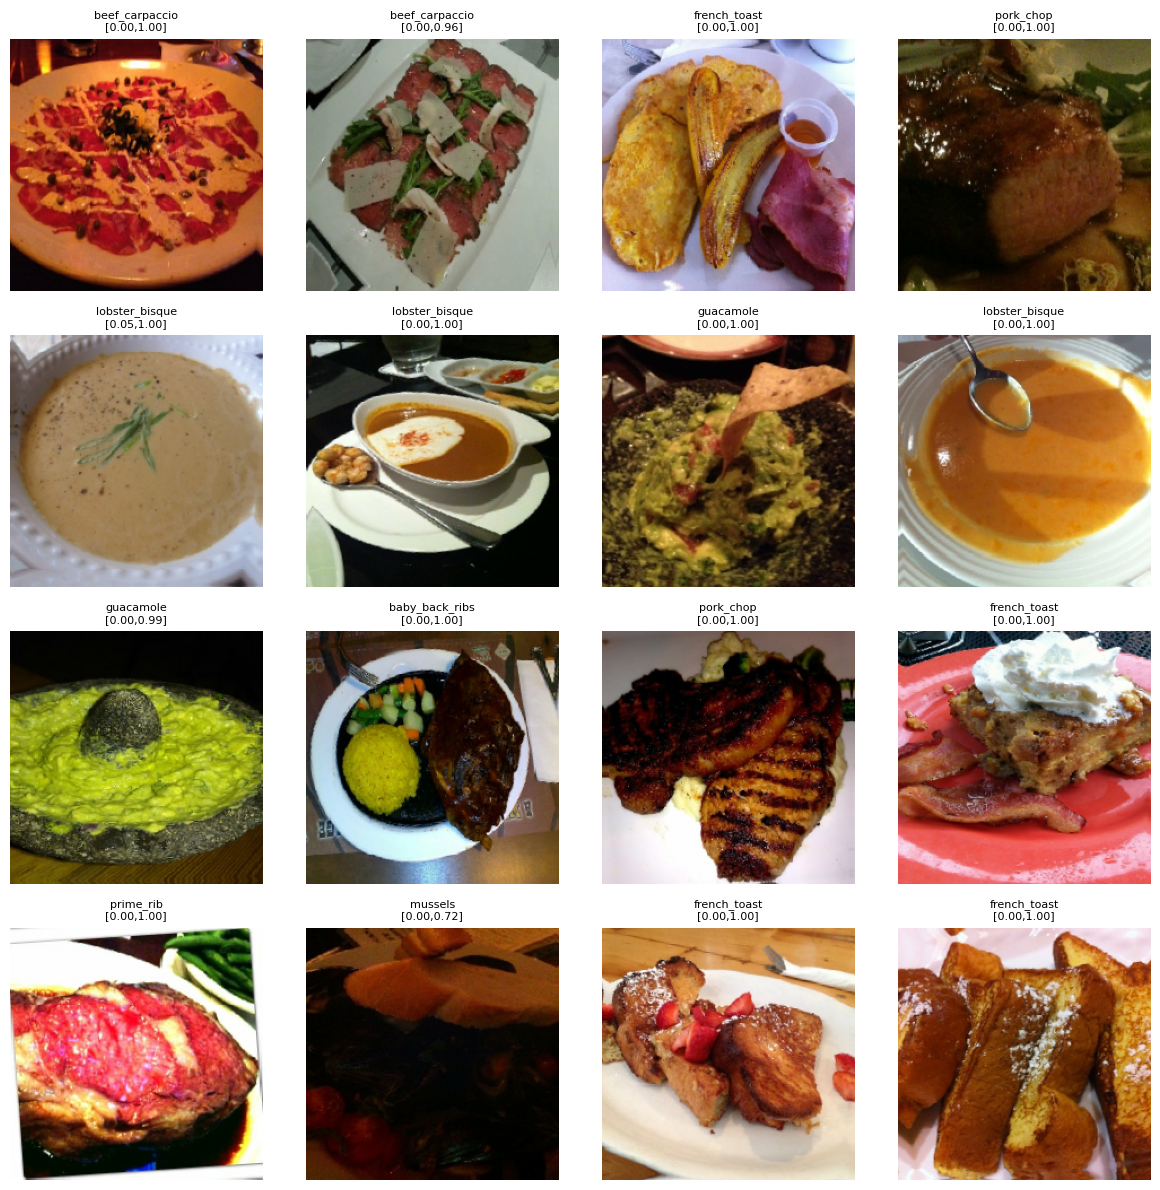


Proses persiapan data selesai.


In [ ]:
# --- Fungsi Pembagian Dataset (Versi Final) ---
def pembagian_dataset(dir_sumber, dir_train, dir_val, dir_test,
                      rasio_train=0.7, rasio_val=0.15, rasio_test=0.15,
                      limit_kategori=None, seed_acak=42):
    """
    Membagi file gambar dari direktori sumber ke direktori train, val, test.
    Secara opsional membatasi jumlah kategori yang diproses secara acak.
    Membuat direktori split jika belum ada.
    """
    assert abs(rasio_train + rasio_val + rasio_test - 1.0) < 1e-10, "Rasio harus berjumlah 1"

    # Pastikan direktori split utama ada
    os.makedirs(dir_train, exist_ok=True)
    os.makedirs(dir_val, exist_ok=True)
    os.makedirs(dir_test, exist_ok=True)

    # 1. Dapatkan semua kategori
    try:
        if not os.path.isdir(dir_sumber):
            raise FileNotFoundError(f"Direktori sumber '{dir_sumber}' tidak ditemukan.")
        kategori_all = sorted([f for f in os.listdir(dir_sumber) if os.path.isdir(os.path.join(dir_sumber, f))])
    except FileNotFoundError as fnf_err:
        print(f"Error: {fnf_err}")
        return {"train": 0, "val": 0, "test": 0, "total": 0, "kategori_dipilih": []}
    except Exception as e:
        print(f"Error saat akses direktori sumber '{dir_sumber}': {e}")
        return {"train": 0, "val": 0, "test": 0, "total": 0, "kategori_dipilih": []}

    if not kategori_all:
        print(f"Error: Tidak ada subdirektori kategori di '{dir_sumber}'.")
        return {"train": 0, "val": 0, "test": 0, "total": 0, "kategori_dipilih": []}

    print(f"Menemukan {len(kategori_all)} kategori total di '{dir_sumber}'.")

    # 2. Pilih kategori berdasarkan limit
    kategori_terpilih = []
    if limit_kategori is not None and limit_kategori > 0:
        if len(kategori_all) > limit_kategori:
            print(f"Memilih {limit_kategori} kategori acak (seed={seed_acak})...")
            random.seed(seed_acak)
            kategori_terpilih = random.sample(kategori_all, limit_kategori)
            print(f"Kategori dipilih: {sorted(kategori_terpilih)}")
        else:
            print(f"Jumlah kategori ({len(kategori_all)}) <= limit ({limit_kategori}). Menggunakan semua.")
            kategori_terpilih = kategori_all
    else:
        print("Limit kategori tidak diset. Menggunakan semua kategori.")
        kategori_terpilih = kategori_all

    if not kategori_terpilih:
         print("Tidak ada kategori yang dipilih untuk diproses.")
         return {"train": 0, "val": 0, "test": 0, "total": 0, "kategori_dipilih": []}

    # 3. Proses pembagian
    print(f"\nMemulai pembagian untuk {len(kategori_terpilih)} kategori...")
    jumlah = {"train": 0, "val": 0, "test": 0, "total": 0}

    for k in kategori_terpilih:
        path_sumber_kategori = os.path.join(dir_sumber, k)
        path_train_kategori = os.path.join(dir_train, k)
        path_val_kategori = os.path.join(dir_val, k)
        path_test_kategori = os.path.join(dir_test, k)

        # Buat direktori tujuan per kategori
        os.makedirs(path_train_kategori, exist_ok=True)
        os.makedirs(path_val_kategori, exist_ok=True)
        os.makedirs(path_test_kategori, exist_ok=True)

        try:
            files = [f for f in os.listdir(path_sumber_kategori)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png')) and
                     os.path.isfile(os.path.join(path_sumber_kategori, f))]

            if not files:
                print(f"Warning: Kategori '{k}' tidak berisi file gambar valid. Lewati.")
                continue

            # Acak file dalam kategori (gunakan seed untuk konsistensi)
            random.seed(seed_acak)
            random.shuffle(files)
            n = len(files)
            jumlah["total"] += n

            akhir_train = int(n * rasio_train)
            akhir_val = akhir_train + int(n * rasio_val)

            # Salin file
            for i, f in enumerate(files):
                src_path = os.path.join(path_sumber_kategori, f)
                try:
                    if i < akhir_train:
                        dest_path = os.path.join(path_train_kategori, f)
                        shutil.copy2(src_path, dest_path)
                        jumlah["train"] += 1
                    elif i < akhir_val:
                        dest_path = os.path.join(path_val_kategori, f)
                        shutil.copy2(src_path, dest_path)
                        jumlah["val"] += 1
                    else:
                        dest_path = os.path.join(path_test_kategori, f)
                        shutil.copy2(src_path, dest_path)
                        jumlah["test"] += 1
                except Exception as copy_err:
                    # Cek error spesifik jika perlu (misal disk penuh)
                    if isinstance(copy_err, OSError) and 'No space left on device' in str(copy_err):
                        print(f"ERROR KRITIKAL: Disk penuh saat menyalin {f}. Menghentikan pembagian.")
                        raise copy_err # Hentikan proses
                    else:
                        print(f"Warning: Gagal salin {f} dari {k}: {copy_err}")

        except FileNotFoundError: # Seharusnya tidak terjadi jika listdir berhasil
            print(f"Warning: Path kategori sumber '{path_sumber_kategori}' tidak ditemukan saat diproses.")
        except Exception as e:
            print(f"Error saat proses kategori '{k}': {e}")

    print("\nPembagian dataset selesai.")
    hasil_akhir = jumlah.copy()
    hasil_akhir["kategori_dipilih"] = sorted(kategori_terpilih)
    return hasil_akhir

# --- Proses Pembagian Dataset (Panggilan Fungsi) ---
image_dir_path = os.path.join(dataset_path, IMAGE_SUBDIR)
print(f"\nMenggunakan direktori gambar sumber: {image_dir_path}")

run_split = True
kategori_di_split = []
# Cek apakah split sudah ada dan valid
if os.path.exists(train_dir):
    try:
        kategori_di_split = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
    except Exception:
        kategori_di_split = []

if kategori_di_split: # Jika ada kategori di direktori train
    print(f"\nDirektori '{train_dir}' sudah berisi {len(kategori_di_split)} kategori. Cek validitas...")
    print(f"Kategori yang ada: {kategori_di_split[:10]}...")

    valid = True
    if JUMLAH_KATEGORI_DIPILIH is not None and JUMLAH_KATEGORI_DIPILIH > 0:
        if len(kategori_di_split) != JUMLAH_KATEGORI_DIPILIH:
            print(f"WARNING: Jumlah kategori ({len(kategori_di_split)}) tidak cocok dengan limit ({JUMLAH_KATEGORI_DIPILIH}).")
            valid = False
            # Anda bisa menambahkan pengecekan nama kategori jika perlu
            # Misalnya, generate ulang nama kategori yg seharusnya dipilih dgn seed yg sama
            # lalu bandingkan. Ini lebih kompleks.

    if valid:
        print("Split yang ada dianggap valid. Melewati proses pembagian.")
        run_split = False
        # Tetapkan nama_kelas dari split yang ada
        nama_kelas = kategori_di_split
    else:
        print(f"--> Menjalankan ulang pembagian. Hapus '{SPLIT_BASE_DIR}' manual jika ingin bersih total.")
        # Tidak perlu menghapus otomatis, biarkan fungsi menimpa
        run_split = True

elif os.path.exists(train_dir): # Direktori train ada tapi kosong
    print(f"Direktori '{train_dir}' ada tapi kosong. Melanjutkan proses pembagian...")
    run_split = True
else: # Direktori train belum ada
    print(f"Direktori '{train_dir}' belum ada. Melanjutkan proses pembagian...")
    run_split = True

# Lakukan pembagian jika diperlukan
if run_split:
    if not os.path.isdir(image_dir_path):
        print(f"Error Fatal: Direktori sumber '{image_dir_path}' tidak valid.")
        exit()
    else:
        print(f"\nMelakukan pembagian dataset (limit: {JUMLAH_KATEGORI_DIPILIH}, seed: {SEED_REPRODUCIBILITY})...")
        hasil_pembagian = pembagian_dataset(
            image_dir_path,
            train_dir, val_dir, test_dir,
            limit_kategori=JUMLAH_KATEGORI_DIPILIH,
            seed_acak=SEED_REPRODUCIBILITY
        )

        # Tampilkan hasil pembagian
        if hasil_pembagian["total"] > 0:
            total = hasil_pembagian['total']
            kategori_diproses = hasil_pembagian['kategori_dipilih']
            print(f"\nKategori yang diproses ({len(kategori_diproses)}): {kategori_diproses}")
            print(f"\nHasil Pembagian Dataset:")
            print(f"- Total gambar diproses : {total}")
            print(f"- Gambar pelatihan      : {hasil_pembagian['train']} ({hasil_pembagian['train']/total:.2%})")
            print(f"- Gambar validasi       : {hasil_pembagian['val']} ({hasil_pembagian['val']/total:.2%})")
            print(f"- Gambar pengujian        : {hasil_pembagian['test']} ({hasil_pembagian['test']/total:.2%})")
            total_split = hasil_pembagian['train'] + hasil_pembagian['val'] + hasil_pembagian['test']
            if total_split != total:
                print(f"WARNING: Jumlah file split ({total_split}) != total diproses ({total}).")
            # Tetapkan nama_kelas dari hasil split
            nama_kelas = kategori_diproses
        else:
             print("Pembagian dataset selesai, tapi tidak ada file yang diproses/disalin.")
             if not hasil_pembagian["kategori_dipilih"]:
                  print("--> Tidak ada kategori yang dipilih atau ditemukan.")
             print("--> Error: Pembagian dijalankan tapi gagal menghasilkan data.")
             exit() # Hentikan jika split gagal total

# --- Persiapan Data dengan tf.data ---
print("\nMenyiapkan pipeline data menggunakan tf.data...")

try:
    # Validasi ulang direktori split sebelum load
    if not os.path.isdir(train_dir) or not any(os.path.isdir(os.path.join(train_dir, item)) for item in os.listdir(train_dir)):
         raise FileNotFoundError(f"Direktori train '{train_dir}' tidak valid atau tidak berisi kategori.")
    if not os.path.isdir(val_dir) or not any(os.path.isdir(os.path.join(val_dir, item)) for item in os.listdir(val_dir)):
         raise FileNotFoundError(f"Direktori validation '{val_dir}' tidak valid atau tidak berisi kategori.")
    if not os.path.isdir(test_dir) or not any(os.path.isdir(os.path.join(test_dir, item)) for item in os.listdir(test_dir)):
         raise FileNotFoundError(f"Direktori test '{test_dir}' tidak valid atau tidak berisi kategori.")

    # Muat dataset dari direktori split
    train_ds_raw = tf.keras.utils.image_dataset_from_directory(
        train_dir, labels='inferred', label_mode='categorical',
        image_size=(TINGGI_GAMBAR, LEBAR_GAMBAR), # Initial resize (optional but common)
        interpolation='nearest', # 'bilinear' lebih halus tapi lambat
        batch_size=None, # Muat sebagai individual images
        shuffle=True, seed=SEED_REPRODUCIBILITY # Shuffle files saat loading
    )
    val_ds_raw = tf.keras.utils.image_dataset_from_directory(
        val_dir, labels='inferred', label_mode='categorical',
        image_size=(TINGGI_GAMBAR, LEBAR_GAMBAR), interpolation='nearest',
        batch_size=None, shuffle=False # No shuffle for val/test
    )
    test_ds_raw = tf.keras.utils.image_dataset_from_directory(
        test_dir, labels='inferred', label_mode='categorical',
        image_size=(TINGGI_GAMBAR, LEBAR_GAMBAR), interpolation='nearest',
        batch_size=None, shuffle=False
    )

    # Dapatkan nama kelas (seharusnya konsisten dengan 'nama_kelas' dari split)
    nama_kelas_loaded = train_ds_raw.class_names
    if not nama_kelas_loaded:
         raise ValueError(f"Gagal memuat nama kelas dari '{train_dir}'.")

    # Konsistensi check (opsional)
    if 'nama_kelas' in locals() and sorted(nama_kelas) != sorted(nama_kelas_loaded):
        print(f"WARNING: Nama kelas dari split ({sorted(nama_kelas)}) berbeda dengan yang dimuat tf.data ({sorted(nama_kelas_loaded)})")
        # Pilih salah satu sebagai sumber kebenaran, misal yang dimuat:
        nama_kelas = nama_kelas_loaded

    print(f"\nNama kelas yang dimuat tf.data ({len(nama_kelas)}): {nama_kelas[:10]}...")
    labels_path = 'labels.txt'
    try:
        with open(labels_path, 'w') as f:
            for nk in nama_kelas: f.write(f"{nk}\n")
        print(f"File '{labels_path}' (kelas terpilih) berhasil disimpan.")
    except Exception as write_err:
        print(f"Warning: Gagal menyimpan '{labels_path}': {write_err}")

except FileNotFoundError as fnf_err:
     print(f"\nError Fatal saat memuat tf.data: {fnf_err}")
     print("Pastikan proses pembagian dataset berhasil.")
     exit()
except Exception as e:
    print(f"\nError saat memuat dataset dari direktori split: {e}")
    import traceback
    traceback.print_exc()
    raise RuntimeError(f"Gagal memuat dataset tf.data: {e}")


# --- Augmentasi Data (Lebih Ringan & Revisi) ---
print("Mengkonfigurasi augmentasi data (lebih ringan, fill_mode='reflect')...")
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=SEED_REPRODUCIBILITY),
    tf.keras.layers.RandomRotation(factor=0.03, # Makin kecil
                                   fill_mode='reflect', # Coba reflect
                                   seed=SEED_REPRODUCIBILITY),
    tf.keras.layers.RandomZoom(height_factor=0.03, width_factor=0.03, # Makin kecil
                               fill_mode='reflect', # Coba reflect
                               interpolation='nearest', # Nearest lebih cepat untuk zoom?
                               seed=SEED_REPRODUCIBILITY),
    # RandomHeight/Width dihapus untuk sementara, bisa ditambahkan kembali jika perlu
    # tf.keras.layers.RandomBrightness(factor=0.03, # Makin kecil
    #                                  seed=SEED_REPRODUCIBILITY)
], name="data_augmentation")


# --- Fungsi Pemrosesan Gambar untuk tf.data ---

# Rescale: Diterapkan SEBELUM cache
@tf.function # Optimasi TensorFlow
def rescale_image(image, label):
    """Cast ke float32 dan rescale ke [0,1]."""
    image = tf.cast(image, tf.float32)
    return image / 255.0, label

# Augment + Resize + Clip: Diterapkan SETELAH cache (hanya untuk train)
@tf.function # Optimasi TensorFlow
def augment_resize_clip(image, label):
    """Terapkan augmentasi, resize akhir, dan clip."""
    # Input: float32 [0,1] dari cache
    image = data_augmentation(image, training=True)
    # Resize kembali (penting setelah zoom/rotasi)
    image = tf.image.resize(image, [TINGGI_GAMBAR, LEBAR_GAMBAR], method='nearest')
    # Clip adalah langkah terakhir untuk memastikan rentang [0,1]
    image = tf.clip_by_value(image, 0.0, 1.0)
    image.set_shape([TINGGI_GAMBAR, LEBAR_GAMBAR, 3]) # Bantu TF inferensi shape
    return image, label

# Resize + Rescale + Clip: Diterapkan untuk val/test (TANPA augmentasi)
@tf.function # Optimasi TensorFlow
def resize_rescale_clip(image, label):
    """Resize, rescale, dan clip untuk data non-training."""
    # Input: uint8 [0,255] dari image_dataset_from_directory
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, [TINGGI_GAMBAR, LEBAR_GAMBAR], method='nearest')
    image = image / 255.0
    image = tf.clip_by_value(image, 0.0, 1.0) # Clip tetap penting
    image.set_shape([TINGGI_GAMBAR, LEBAR_GAMBAR, 3])
    return image, label

# --- Membangun Pipeline tf.data (Final) ---

print("\nMembangun pipeline data training...")
train_ds = (
    train_ds_raw
    .map(rescale_image, num_parallel_calls=AUTOTUNE)       # 1. Rescale [0,1]
    .cache()                                               # 2. Cache
    .shuffle(buffer_size=max(1000, UKURAN_BATCH*5), seed=SEED_REPRODUCIBILITY) # 3. Shuffle (buffer bisa lebih kecil jika memori terbatas)
    .map(augment_resize_clip, num_parallel_calls=AUTOTUNE) # 4. Augment, Resize, Clip
    .batch(UKURAN_BATCH)                                   # 5. Batch
    .prefetch(buffer_size=AUTOTUNE)                        # 6. Prefetch
)

print("Membangun pipeline data validasi...")
val_ds = (
    val_ds_raw
    .map(resize_rescale_clip, num_parallel_calls=AUTOTUNE) # 1. Resize, Rescale, Clip
    .cache()                                               # 2. Cache
    .batch(UKURAN_BATCH)                                   # 3. Batch
    .prefetch(buffer_size=AUTOTUNE)                        # 4. Prefetch
)

print("Membangun pipeline data test...")
test_ds = (
    test_ds_raw
    .map(resize_rescale_clip, num_parallel_calls=AUTOTUNE) # 1. Resize, Rescale, Clip
    .cache()                                               # 2. Cache
    .batch(UKURAN_BATCH)                                   # 3. Batch
    .prefetch(buffer_size=AUTOTUNE)                        # 4. Prefetch
)

print("\nPipeline tf.data (train_ds, val_ds, test_ds) siap digunakan.")


# --- Visualisasi Sampel Batch ---
def tampilkan_batch(image_batch_np, label_batch_np, class_names_list):
    """Menampilkan grid gambar dari batch numpy."""
    plt.figure(figsize=(12, 12)) # Sedikit lebih besar
    num_images_to_show = min(16, len(image_batch_np)) # Tampilkan hingga 16
    grid_size = int(np.ceil(np.sqrt(num_images_to_show)))
    for i in range(num_images_to_show):
        ax = plt.subplot(grid_size, grid_size, i + 1)
        img_display = image_batch_np[i]
        # Cek range sebelum display
        img_min, img_max = img_display.min(), img_display.max()
        if img_min < -0.01 or img_max > 1.01:
             print(f"Warning: Img {i} range [{img_min:.2f}, {img_max:.2f}]. Clipping for display.")
             img_display = np.clip(img_display, 0.0, 1.0)

        plt.imshow(img_display)

        label_index = np.argmax(label_batch_np[i])
        title = f"Idx: {label_index}" # Default title
        if class_names_list and label_index < len(class_names_list):
            title = f"{class_names_list[label_index]}"
        # Tambahkan info range ke judul untuk debug
        title += f"\n[{img_min:.2f},{img_max:.2f}]"
        plt.title(title, fontsize=8)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

print("\nMenampilkan sampel batch dari train_ds (setelah augmentasi)...")
try:
    for image_batch, label_batch in train_ds.take(1):
        print(f"Shape image batch: {image_batch.shape}, Type: {image_batch.dtype}")
        min_val = tf.reduce_min(image_batch).numpy()
        max_val = tf.reduce_max(image_batch).numpy()
        print(f"Rentang nilai piksel batch: [{min_val:.3f}, {max_val:.3f}]")

        # Pastikan nama_kelas ada
        if 'nama_kelas' not in locals(): nama_kelas = None

        tampilkan_batch(image_batch.numpy(), label_batch.numpy(), nama_kelas)
        break
except tf.errors.OutOfRangeError:
     print("Error: Dataset training kosong atau tidak bisa diambil batchnya.")
except Exception as e:
    print(f"Gagal mengambil/menampilkan sampel batch: {e}")
    import traceback
    traceback.print_exc()

print("\nProses persiapan data selesai.")

## Modelling

In [10]:
# --- Periksa Variabel Dataset ---
if 'train_ds' not in locals() or 'val_ds' not in locals() or 'test_ds' not in locals() or 'nama_kelas' not in locals():
    raise NameError("Pastikan dataset 'train_ds', 'val_ds', 'test_ds', dan 'nama_kelas' sudah didefinisikan dari langkah sebelumnya.")

if not nama_kelas:
      raise ValueError("Variabel 'nama_kelas' kosong. Tidak bisa melanjutkan.")

JUMLAH_KELAS = len(nama_kelas)
print(f"Jumlah kelas terdeteksi: {JUMLAH_KELAS}")

# --- Callback ---
class CallbackAmbangAkurasi(Callback):
    def __init__(self, ambang=0.94):
        super().__init__()
        self.ambang = ambang
        print(f"CallbackAmbangAkurasi diinisialisasi dengan ambang: {self.ambang}")

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current_acc = logs.get('accuracy')
        current_val_acc = logs.get('val_accuracy')

        if current_acc is not None and current_val_acc is not None:
            if current_acc >= self.ambang and current_val_acc >= self.ambang:
                print(f"\nEpoch {epoch+1}: Akurasi train ({current_acc:.4f}) dan validasi ({current_val_acc:.4f}) >= {self.ambang*100:.0f}%. Menghentikan pelatihan.")
                self.model.stop_training = True

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6, verbose=1)
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_cb = TensorBoard(log_dir=log_dir, histogram_freq=1)
ambang_cb = CallbackAmbangAkurasi(ambang=0.90)
os.makedirs('saved_model', exist_ok=True)
checkpoint = ModelCheckpoint('saved_model/best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
callbacks_list = [early_stopping, reduce_lr, checkpoint, tensorboard_cb, ambang_cb]
print(f"Callbacks yang digunakan: {[cb.__class__.__name__ for cb in callbacks_list]}")

# --- Bangun Model (Dengan Modifikasi) ---
print("\nMembangun model...")

# Pastikan TINGGI_GAMBAR dan LEBAR_GAMBAR sudah ada
try:
    input_shape = (TINGGI_GAMBAR, LEBAR_GAMBAR, 3)
except NameError:
    raise NameError("Variabel TINGGI_GAMBAR dan LEBAR_GAMBAR belum didefinisikan.")

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
base_model.trainable = False # Bekukan base model untuk pelatihan awal
print(f"Base model 'trainable' untuk pelatihan awal: {base_model.trainable}")

# Tambahkan layer kustom di atas base model
model = models.Sequential([
    base_model,
    # ===> TAMBAHKAN LAPISAN CONV2D SECARA EKSPLISIT DI SINI <===
    layers.Conv2D(256, (3, 3), padding='same', activation='relu', name='explicit_conv2d'), # Contoh Conv2D layer
    layers.BatchNormalization(name='explicit_bn'), # Optional, tapi sering membantu setelah Conv2D
    # ============================================================
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(), # BN setelah Dense
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(), # BN setelah Dense
    layers.Dropout(0.3),
    layers.Dense(JUMLAH_KELAS, activation='softmax')
], name="best_model.keras") # Update nama model jika perlu

# --- Kompilasi Model (Initial) ---
initial_learning_rate = 0.001
model.compile(
    optimizer=optimizers.Adam(learning_rate=initial_learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("\n--- Ringkasan Model (Setelah Menambah Conv2D, Sebelum Pelatihan Awal) ---")
model.summary() # Perhatikan penambahan parameter dari layer Conv2D baru

# --- Latih Model (Initial Training) ---
print("\n--- Memulai Pelatihan Awal (Transfer Learning) ---")
EPOCHS_INITIAL = 50

history = model.fit(
    train_ds,
    epochs=EPOCHS_INITIAL,
    validation_data=val_ds,
    callbacks=callbacks_list
)
print("\nPelatihan awal selesai.")

# --- Fine-tuning ---
print("\n--- Mempersiapkan Fine-Tuning ---")
base_model.trainable = True
print(f"Base model 'trainable' untuk fine-tuning: {base_model.trainable}")

fine_tune_at = len(base_model.layers) - 70
if fine_tune_at < 0: fine_tune_at = 0

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Penting: Jangan bekukan layer Conv2D dan BN eksplisit yang baru ditambahkan
# Pastikan layer 'explicit_conv2d' dan 'explicit_bn' (jika ditambahkan) tetap trainable
# Jika Anda menambahkan layer ini, mereka secara default akan trainable,
# jadi tidak perlu tindakan khusus di sini KECUALI Anda secara eksplisit
# membekukannya di tempat lain. Loop di atas hanya membekukan layer *di dalam* base_model.

trainable_layers_total = sum(1 for layer in model.layers if layer.trainable)
trainable_layers_in_base = sum(1 for layer in base_model.layers if layer.trainable)
print(f"Lapisan yang dibekukan di base model: {len(base_model.layers) - trainable_layers_in_base}")
print(f"Jumlah lapisan yang dapat dilatih di base model setelah unfreeze: {trainable_layers_in_base}")
print(f"Jumlah total lapisan yang dapat dilatih dalam model (termasuk top layers): {trainable_layers_total}")

# Kompilasi ulang model dengan learning rate yang lebih rendah untuk fine-tuning
fine_tune_learning_rate = initial_learning_rate / 10
model.compile(
    optimizer=optimizers.Adam(learning_rate=fine_tune_learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print(f"\nModel dikompilasi ulang untuk fine-tuning dengan LR: {fine_tune_learning_rate}")
print("\n--- Ringkasan Model (Sebelum Fine-Tuning) ---")
model.summary()

print("\n--- Memulai Fine-Tuning ---")
EPOCHS_FINE_TUNE = 30
total_epochs = EPOCHS_INITIAL + EPOCHS_FINE_TUNE

# Lanjutkan training (fine-tuning)
# Dapatkan epoch terakhir dari history sebelumnya
last_epoch = history.epoch[-1] if history.epoch else -1 # Handle jika history kosong

fine_tune_history = model.fit(
    train_ds,
    epochs=total_epochs,
    initial_epoch=last_epoch + 1, # Mulai dari epoch setelah training awal selesai
    validation_data=val_ds,
    callbacks=callbacks_list
)
print("\nFine-tuning selesai.")

Jumlah kelas terdeteksi: 9
CallbackAmbangAkurasi diinisialisasi dengan ambang: 0.9
Callbacks yang digunakan: ['EarlyStopping', 'ReduceLROnPlateau', 'ModelCheckpoint', 'TensorBoard', 'CallbackAmbangAkurasi']

Membangun model...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model 'trainable' untuk pelatihan awal: False

--- Ringkasan Model (Setelah Menambah Conv2D, Sebelum Pelatihan Awal) ---


Model: "best_model.keras"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ explicit_conv2d (Conv2D)        │ (None, 7, 7, 256)      │     2,949,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ explicit_bn                     │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,476,681 (20.89 MB)

 Trainable params: 3,216,649 (12.27 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ explicit_conv2d (Conv2D)        │ (None, 7, 7, 256)      │     2,949,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ explicit_bn                     │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,476,681 (20.89 MB)

 Trainable params: 5,230,089 (19.95 MB)

 Non-trainable params: 246,592 (963.25 KB)


--- Memulai Fine-Tuning ---
Epoch 14/80
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7901 - loss: 0.6706
Epoch 14: val_accuracy did not improve from 0.85026
197/197 ━━━━━━━━━━━━━━━━━━━━ 757s 4s/step - accuracy: 0.7903 - loss: 0.6700 - val_accuracy: 0.7761 - val_loss: 0.8255 - learning_rate: 1.0000e-04
Epoch 15/80
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8766 - loss: 0.3634
Epoch 15: val_accuracy did not improve from 0.85026
197/197 ━━━━━━━━━━━━━━━━━━━━ 753s 4s/step - accuracy: 0.8767 - loss: 0.3633 - val_accuracy: 0.8421 - val_loss: 0.5469 - learning_rate: 1.0000e-04
Epoch 16/80
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9158 - loss: 0.2451
Epoch 16: val_accuracy did not improve from 0.85026
197/197 ━━━━━━━━━━━━━━━━━━━━ 803s 4s/step - accuracy: 0.9158 - loss: 0.2451 - val_accuracy: 0.8213 - val_loss: 0.6050 - learning_rate: 1.0000e-04
Epoch 17/80
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9396 - loss: 0.1860
Epoch 17: val_accuracy did not im

## Evaluasi dan Visualisasi


Menggabungkan history pelatihan...
History dari fine-tuning berhasil digabungkan.

--- Mengevaluasi Model pada Data Test ---
Memuat bobot model terbaik dari checkpoint 'saved_model/best_model.keras'...
Bobot model terbaik berhasil dimuat.
43/43 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.8657 - loss: 0.4248

Hasil Evaluasi Data Test:
  Loss Test     : 0.4466
  Akurasi Test  : 0.8749 (87.49%)

Membuat plot akurasi dan loss...


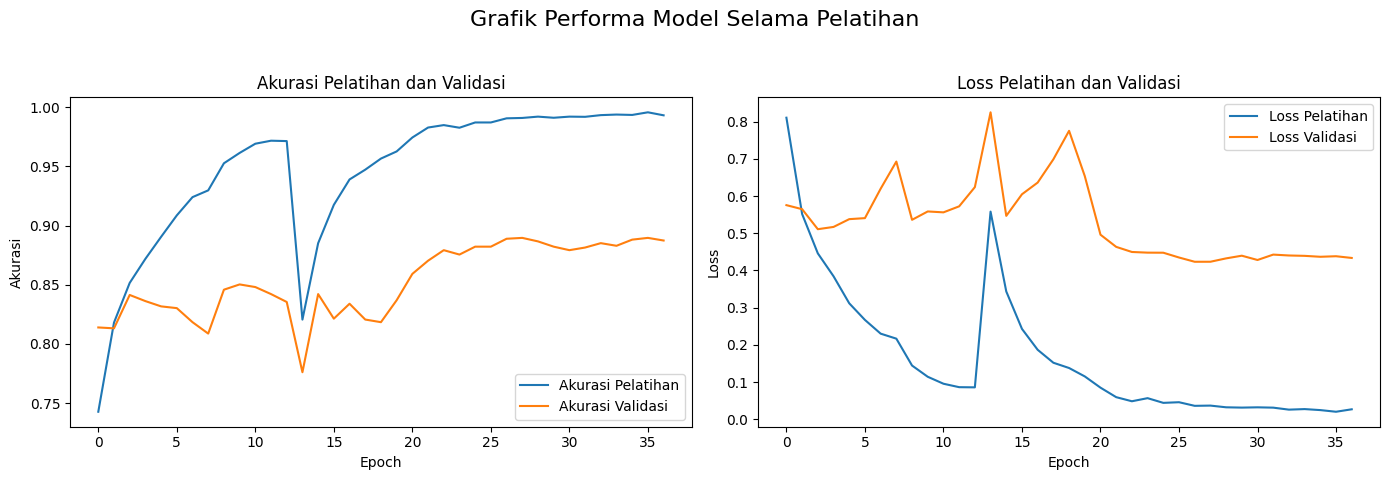


--- Membuat Laporan Klasifikasi dan Confusion Matrix ---
Memprediksi data test...
43/43 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step
Mengambil label sebenarnya dari data test...
Jumlah sampel untuk laporan klasifikasi: 1351

Laporan Klasifikasi (Test Set):
                precision    recall  f1-score   support

baby_back_ribs       0.86      0.79      0.82       150
beef_carpaccio       0.89      0.92      0.90       151
  french_toast       0.84      0.88      0.86       150
     guacamole       0.94      0.90      0.92       150
lobster_bisque       0.94      0.97      0.96       150
      macarons       0.96      0.97      0.97       150
       mussels       0.96      0.89      0.92       150
     pork_chop       0.70      0.73      0.71       150
     prime_rib       0.81      0.83      0.82       150

      accuracy                           0.87      1351
     macro avg       0.88      0.87      0.88      1351
  weighted avg       0.88      0.87      0.88      1351


Menampilkan Confusion 

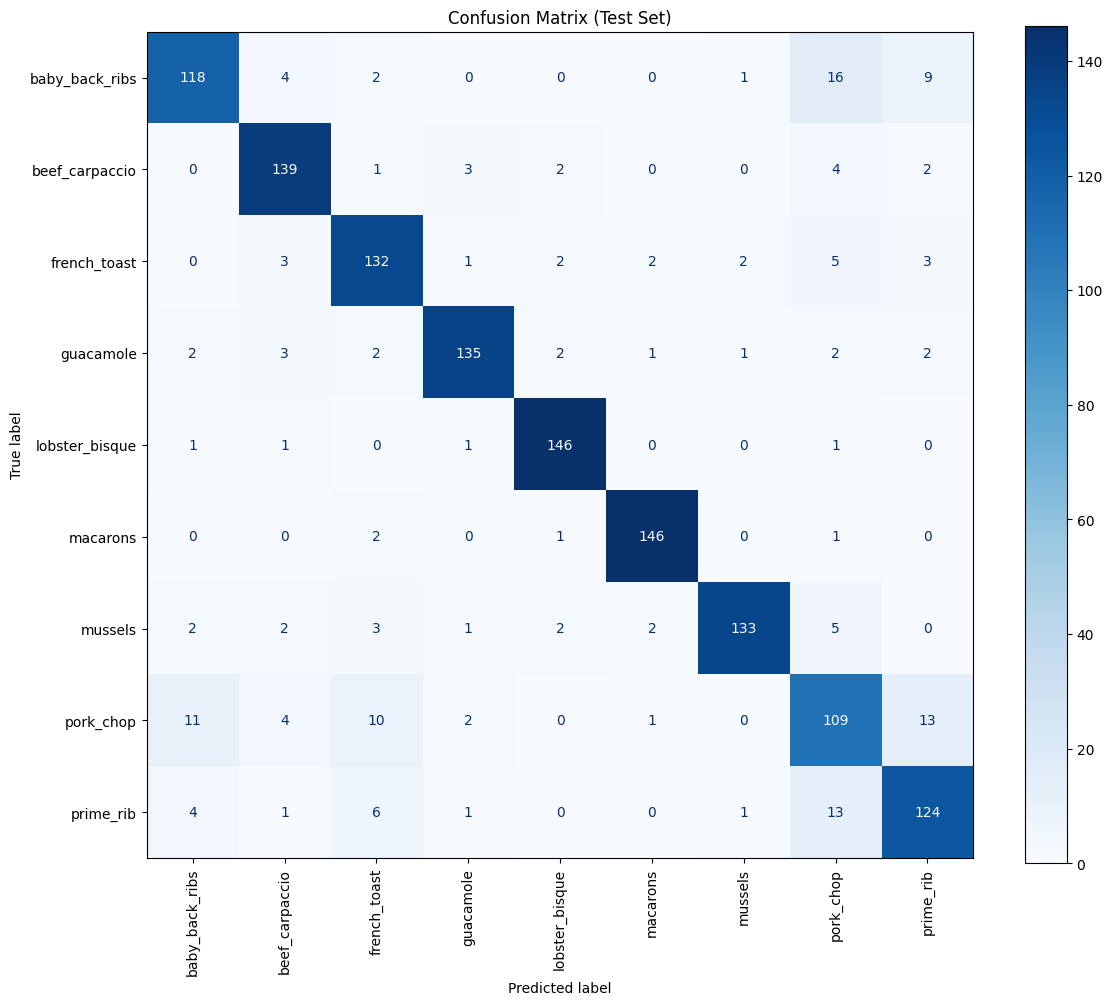


--- Menyimpan Model Final ---
Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_158')
Output Type:
  TensorSpec(shape=(None, 9), dtype=tf.float32, name=None)
Captures:
  137446416918352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137446416920848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137446416921040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137446416920272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137446416919504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137446416920464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137446416922768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137446416919888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137446416921808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137446416919312: TensorSpec(shape=(), dtype=tf.resourc

In [11]:
# --- Gabungkan History Pelatihan ---
print("\nMenggabungkan history pelatihan...")
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Tambahkan history dari fine-tuning jika ada
if 'fine_tune_history' in locals() and fine_tune_history is not None:
    acc.extend(fine_tune_history.history['accuracy'])
    val_acc.extend(fine_tune_history.history['val_accuracy'])
    loss.extend(fine_tune_history.history['loss'])
    val_loss.extend(fine_tune_history.history['val_loss'])
    print("History dari fine-tuning berhasil digabungkan.")
else:
    print("Tidak ada history fine-tuning untuk digabungkan (mungkin berhenti lebih awal).")

# --- Evaluasi Model pada Test Set ---
print("\n--- Mengevaluasi Model pada Data Test ---")
# Pastikan kita mengevaluasi model TERBAIK yang disimpan oleh checkpoint
print("Memuat bobot model terbaik dari checkpoint 'saved_model/best_model.keras'...")
try:
    model.load_weights('saved_model/best_model.keras')
    print("Bobot model terbaik berhasil dimuat.")
except Exception as e:
    print(f"Gagal memuat bobot dari 'saved_model/best_model.keras'. Mengevaluasi model terakhir. Error: {e}")

test_loss, test_accuracy = model.evaluate(test_ds) # Gunakan test_ds (tf.data.Dataset)
print(f"\nHasil Evaluasi Data Test:")
print(f"  Loss Test     : {test_loss:.4f}")
print(f"  Akurasi Test  : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# --- Visualisasi Hasil Pelatihan ---
print("\nMembuat plot akurasi dan loss...")
epochs_range = range(len(acc)) # Jumlah epoch aktual yang dijalankan

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Akurasi Pelatihan')
plt.plot(epochs_range, val_acc, label='Akurasi Validasi')
plt.legend(loc='lower right')
plt.title('Akurasi Pelatihan dan Validasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Loss Pelatihan')
plt.plot(epochs_range, val_loss, label='Loss Validasi')
plt.legend(loc='upper right')
plt.title('Loss Pelatihan dan Validasi')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.suptitle('Grafik Performa Model Selama Pelatihan', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

# --- Confusion Matrix dan Classification Report ---
print("\n--- Membuat Laporan Klasifikasi dan Confusion Matrix ---")
# Dapatkan prediksi dari model pada data test
print("Memprediksi data test...")
# Prediksi menghasilkan probabilitas untuk setiap kelas
y_pred_probs = model.predict(test_ds)
# Ambil indeks kelas dengan probabilitas tertinggi sebagai prediksi
y_pred = np.argmax(y_pred_probs, axis=1)

# Dapatkan label sebenarnya (true labels) dari test_ds
print("Mengambil label sebenarnya dari data test...")
y_true = []
# Iterasi melalui dataset test untuk mengumpulkan semua label
for images, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1)) # Konversi dari one-hot ke indeks kelas

# Pastikan jumlah prediksi dan label sebenarnya cocok
if len(y_pred) != len(y_true):
     # Ini bisa terjadi jika batch terakhir tidak penuh dan predict/iterate berbeda
     # Coba potong y_pred agar sesuai y_true jika y_pred lebih panjang
     print(f"Warning: Jumlah prediksi ({len(y_pred)}) tidak cocok dengan jumlah label asli ({len(y_true)}). Memotong prediksi...")
     min_len = min(len(y_pred), len(y_true))
     y_pred = y_pred[:min_len]
     y_true = y_true[:min_len]

print(f"Jumlah sampel untuk laporan klasifikasi: {len(y_true)}")

# Cetak Laporan Klasifikasi
print("\nLaporan Klasifikasi (Test Set):")
print(classification_report(y_true, y_pred, target_names=nama_kelas, zero_division=0))

# Tampilkan Confusion Matrix
print("\nMenampilkan Confusion Matrix (Test Set)...")
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nama_kelas)

fig, ax = plt.subplots(figsize=(12, 10)) # Sesuaikan ukuran sesuai jumlah kelas
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

# --- Simpan Model Final ---
# Simpan dalam format SavedModel (direkomendasikan untuk deployment)
print("\n--- Menyimpan Model Final ---")
model.export('saved_model')
print("Model telah disimpan dalam format SavedModel di direktori 'saved_model'")
# Simpan juga dalam format .keras jika diinginkan (mungkin sama dengan checkpoint terbaik)
# model.save('food_classifier_final.keras')
# print("Model juga disimpan dalam format .keras di 'food_classifier_final.keras'")

print("\n===== Proses Selesai =====")

## Konversi Model

In [20]:
# Konversi ke TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_saved_model('saved_model')
tflite_model = converter.convert()
with open('model.tflite', 'wb') as f:
    f.write(tflite_model)
print("Model dikonversi ke format TFLite")

# Buat direktori dan salin label
os.makedirs('saved_model/tflite', exist_ok=True)
shutil.copy('model.tflite', 'saved_model/tflite/model.tflite')
shutil.copy('labels.txt',   'saved_model/tflite/labels.txt')
print("Model TFLite dan label disalin ke direktori tflite")

Model dikonversi ke format TFLite
Model TFLite dan label disalin ke direktori tflite


In [18]:
# Konversi ke format TensorFlow.js
os.makedirs('tfjs_model', exist_ok=True)
!tensorflowjs_converter --input_format=tf_saved_model --saved_model_tags=serve ./saved_model ./saved_model/tfjs/

print("Model dikonversi ke format TensorFlow.js")

2025-05-03 15:05:39.971767: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746284740.031770  154835 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746284740.044936  154835 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
🌲 Try https://ydf.readthedocs.io, the successor of TensorFlow Decision Forests with more features and faster training!
2025-05-03 15:05:50.967405: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
I0000 00:00:1746284752.638725  154835 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
I0000 00:00

## Inference (Optional)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


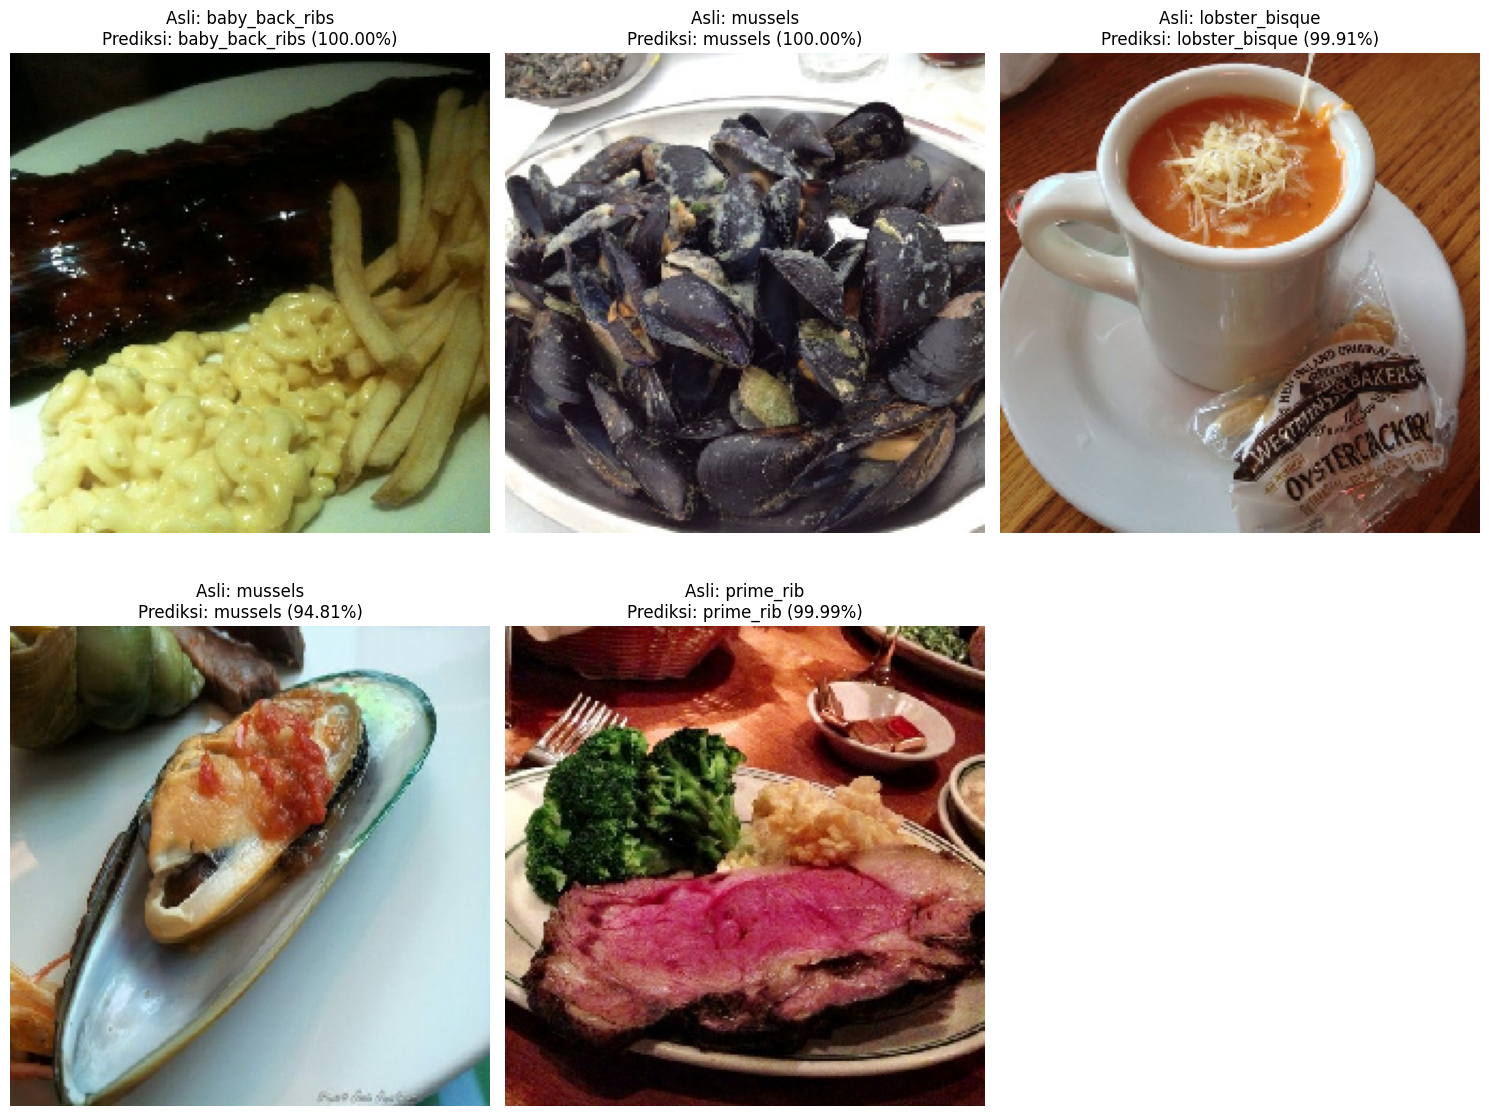

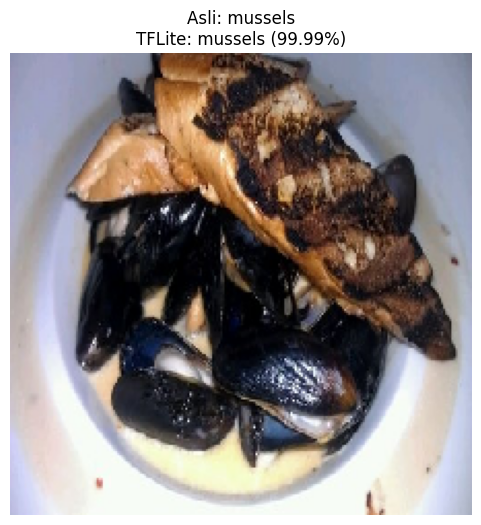

In [14]:
# Inference Keras
def prediksi_gambar(jalur_img, model):
    img = image.load_img(jalur_img, target_size=(TINGGI_GAMBAR, LEBAR_GAMBAR))
    arr = image.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)
    pred = model.predict(arr)
    idx = np.argmax(pred[0]); conf = float(np.max(pred[0]) * 100)
    return idx, conf, img

def uji_gambar_acak(dir_test, model, jumlah_gambar=5):
    plt.figure(figsize=(15, 12))
    kategori = os.listdir(dir_test)
    for i in range(jumlah_gambar):
        ki = random.choice(kategori)
        fi = random.choice([f for f in os.listdir(f"{dir_test}/{ki}")])
        path = f"{dir_test}/{ki}/{fi}"
        idx, conf, img = prediksi_gambar(path, model)
        plt.subplot(2,3,i+1)
        plt.imshow(img)
        plt.title(f"Asli: {ki}\nPrediksi: {nama_kelas[idx]} ({conf:.2f}%)")
        plt.axis("off")
    plt.tight_layout(); plt.show()

uji_gambar_acak('food41_split_limited/test', model)

# Inference TFLite
def uji_model_tflite(jalur_tflite, jalur_img, jalur_label):
    interpreter = tf.lite.Interpreter(model_path=jalur_tflite)
    interpreter.allocate_tensors()
    inp = interpreter.get_input_details(); out = interpreter.get_output_details()
    img = image.load_img(jalur_img, target_size=(TINGGI_GAMBAR, LEBAR_GAMBAR))
    arr = np.expand_dims(image.img_to_array(img)/255.0, axis=0).astype(np.float32)
    interpreter.set_tensor(inp[0]['index'], arr)
    interpreter.invoke()
    data = interpreter.get_tensor(out[0]['index'])[0]
    idx, conf = int(np.argmax(data)), float(np.max(data)*100)
    label_list = open(jalur_label).read().splitlines()
    return label_list[idx], conf, img

sample_dir = random.choice(os.listdir('food41_split_limited/test'))
sample_file = random.choice(os.listdir(f'food41_split_limited/test/{sample_dir}'))
lbl, conf, img = uji_model_tflite('model.tflite', f'food41_split_limited/test/{sample_dir}/{sample_file}', 'labels.txt')
plt.figure(figsize=(6,6)); plt.imshow(img)
plt.title(f"Asli: {sample_dir}\nTFLite: {lbl} ({conf:.2f}%)"); plt.axis("off"); plt.show()


In [23]:
# Buat requirements.txt
%pip freeze > requirements.txt

In [24]:
# Membuat file README.md
# Tambahkan encoding='utf-8' saat membuka file
with open('README.md', 'w', encoding='utf-8') as f:
    f.write("""# Klasifikasi Gambar Food-41

## Ringkasan
Proyek ini mengimplementasikan model klasifikasi gambar menggunakan dataset Food-41 (41 kategori makanan, >10.000 gambar).
Pipeline meliputi:
1.  **Download** dataset via sumber Kaggle ([kmader/food41](https://www.kaggle.com/kmader/food41)), kemungkinan menggunakan KaggleHub atau library terkait, ke dalam direktori `datasets/`.
2.  **Split** data menjadi train/validation/test (70/15/15) ke dalam direktori `food41_split/`.
3.  **Preprocessing** & **augmentasi** dengan `ImageDataGenerator`.
4.  **Transfer learning**: MobileNetV2 + top layers custom.
5.  **Callbacks**: EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TensorBoard (log di `logs/fit/`), custom threshold 85%.
6.  **Training** & **fine-tuning** (target total ≥ 45 epoch).
7.  **Evaluasi**: plot loss/accuracy, confusion matrix, classification report.
8.  **Export** model ke SavedModel, TFLite, dan TensorFlow.js ke dalam direktori `model_output/`.
9.  **Inference** dengan Keras, TFLite, dan (opsional) TFJS.

## Dataset
-   **Sumber**: [kmader/food41](https://www.kaggle.com/kmader/food41)
-   **Lokasi Unduh**: `datasets/food-41/`
-   **Lokasi Split**: `food41_split/` (train/validation/test)
-   **Total gambar**: >10.000
-   **Kategori**: 41 jenis makanan
-   **Format**: .jpg/.png

## Arsitektur Model
-   **Base**: `MobileNetV2` pretrained ImageNet (tanpa top).
-   **Head**:
    -   GlobalAveragePooling2D
    -   Dense(512, relu) + BatchNorm + Dropout(0.5)
    -   Dense(256, relu) + BatchNorm + Dropout(0.3)
    -   Dense(41, softmax)

## Performa (Target/Hasil)
-   **Train Accuracy**: >95%
-   **Val Accuracy**: >90%
-   **Test Accuracy**: >90%

## File & Direktori Penting
-   `datasets/`
    -   `food-41/`: Folder berisi dataset asli yang diunduh.
-   `food41_split/`: Folder berisi data train/validation/test hasil pemisahan.
    -   `train/`
    -   `validation/`
    -   `test/`
-   `logs/`
    -   `fit/`: Direktori berisi log TensorBoard dari proses training.
-   `model_output/`: Direktori berisi semua hasil ekspor model dan label.
    -   `saved_model/`: Model dalam format TensorFlow SavedModel.
    -   `tfjs_model/`: Model dalam format TensorFlow.js (`model.json` + shard `.bin`).
    -   `model.tflite`: File model dalam format TensorFlow Lite.
    -   `labels.txt`: File teks berisi daftar nama kelas/kategori makanan.
-   `Proyek_Klasifikasi_Gambar_V3.ipynb`: Jupyter notebook utama proyek.
-   `README.md`: File ini.
-   `requirements.txt`: Daftar dependensi Python.

## Cara Pakai

1.  **Clone Repositori:**
    ```bash
    git clone [https://github.com/KillerKing93/Dicoding-Proyek-Klasifikasi-Gambar/](https://github.com/KillerKing93/Dicoding-Proyek-Klasifikasi-Gambar/)
    cd Dicoding-Proyek-Klasifikasi-Gambar
    ```

2.  **Buat dan Aktifkan Lingkungan Virtual (Sangat Direkomendasikan):**
    Menggunakan lingkungan virtual (`venv`) membantu mengisolasi paket Python yang dibutuhkan oleh proyek ini dari paket lain di sistem Anda. Ini mencegah potensi konflik versi.

    * **Buat Lingkungan Virtual:**
        Buka terminal atau command prompt di direktori proyek Anda, lalu jalankan:
        ```bash
        python -m venv venv
        ```
        *(Jika Anda memiliki Python 2 dan 3 terinstal, Anda mungkin perlu menggunakan `python3 -m venv venv`)*
        Ini akan membuat folder baru bernama `venv` di dalam direktori proyek Anda.

    * **Aktifkan Lingkungan Virtual:**
        Cara mengaktifkannya berbeda tergantung pada sistem operasi dan shell yang Anda gunakan:
        * **Linux / macOS (Bash/Zsh):**
            ```bash
            source venv/bin/activate
            ```
        * **Windows (Command Prompt):**
            ```cmd
            .\venv\Scripts\activate.bat
            ```
            *(Terkadang cukup dengan: `venv\Scripts\activate`)*
        * **Windows (PowerShell):**
            ```powershell
            .\venv\Scripts\Activate.ps1
            ```
            *(Catatan: Jika Anda mendapatkan error terkait eksekusi skrip, Anda mungkin perlu menjalankan PowerShell sebagai Administrator dan mengetik: `Set-ExecutionPolicy RemoteSigned -Scope CurrentUser`, lalu tekan 'Y' untuk konfirmasi.)*
        * **Windows (Git Bash):**
            ```bash
            source venv/Scripts/activate
            ```
        Setelah aktivasi berhasil, Anda akan melihat `(venv)` muncul di awal baris prompt terminal Anda, menandakan bahwa lingkungan virtual sedang aktif.

3.  **Instal Dependensi:**
    Pastikan lingkungan virtual Anda sudah aktif (lihat langkah 2). Kemudian, instal semua paket yang diperlukan dari file `requirements.txt`:
    ```bash
    pip install -r requirements.txt
    ```
    *(Pastikan file `requirements.txt` ada di direktori proyek dan berisi daftar library yang benar seperti tensorflow, numpy, matplotlib, scikit-learn, dll.)*

4.  **Jalankan Notebook:**
    Sekarang Anda siap menjalankan notebook. Buka dan jalankan file `Proyek_Klasifikasi_Gambar_V3.ipynb` dari sel paling atas hingga akhir menggunakan Jupyter Notebook, Jupyter Lab, Google Colab (jika diunggah), atau VS Code. Proses ini akan:
    * Mengunduh data ke `datasets/food-41/`.
    * Membuat split data di `food41_split/`.
    * Melatih model (log disimpan di `logs/fit/`).
    * Mengevaluasi model.
    * Menyimpan semua output model dan label ke dalam direktori `model_output/`.

5.  **Hasil Model:**
    Semua artefak model (`saved_model/`, `tfjs_model/`, `model.tflite`) dan `labels.txt` akan ditemukan di dalam direktori `model_output/`.

6.  **Inference:**
    Untuk melakukan prediksi pada gambar baru, lihat implementasi fungsi `prediksi_gambar` (untuk model Keras/SavedModel) dan `uji_model_tflite` (untuk model TFLite) yang ada di dalam notebook. Sesuaikan path ke model jika diperlukan untuk menunjuk ke dalam `model_output/`.

7.  **Nonaktifkan Lingkungan Virtual (Opsional):**
    Jika Anda sudah selesai bekerja dengan proyek ini, Anda dapat menonaktifkan lingkungan virtual dengan mengetik perintah berikut di terminal Anda:
    ```bash
    deactivate
    ```
    Prompt terminal Anda akan kembali normal.

## Penulis
-   **Nama:** Alif Nurhidayat (KillerKing93)
-   **Email:** alifnurhidayatwork@gmail.com
-   **GitHub:** [https://github.com/KillerKing93](https://github.com/KillerKing93)

---
*README ini diperbarui berdasarkan struktur direktori aktual proyek dan menyertakan instruksi venv yang lebih detail.*
""")
print("✅ README.md berhasil dibuat")

✅ README.md berhasil dibuat


In [25]:
from google.colab import files

def zip_and_download_folder(folder_path='/content', output_zip_name=None, exclude_folders=None):
  """
  Mengkompres (zip) isi folder yang ditentukan di Google Colab dan
  memicu unduhan file zip tersebut ke komputer lokal Anda.
  Secara default mengecualikan folder 'datasets' dan 'food41_split'
  jika ditemukan langsung di dalam folder_path utama.

  Args:
    folder_path (str): Path absolut ke folder yang ingin di-zip (default: '/content').
    output_zip_name (str, optional): Nama file untuk arsip zip yang akan dibuat.
                                   Jika None, nama default dengan timestamp akan dibuat.
    exclude_folders (list, optional): Daftar nama folder tambahan yang ingin
                                      dikecualikan jika berada langsung di
                                      dalam folder_path utama.
                                      Defaultnya adalah ['datasets', 'food41_split'].
  """
  folder_path = folder_path.rstrip('/') # Hapus garis miring di akhir jika ada

  # Buat nama zip default dengan timestamp jika tidak disediakan
  if output_zip_name is None:
      timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
      # Ambil nama folder terakhir sebagai bagian dari nama zip jika bukan /content
      base_folder_name = os.path.basename(folder_path) if os.path.basename(folder_path) else 'content'
      output_zip_name = f"colab_{base_folder_name}_{timestamp}.zip"

  # Tentukan path absolut untuk file zip (disarankan di /content agar mudah diunduh)
  zip_path = os.path.join('/content', output_zip_name)

  # Tentukan folder default yang akan dikecualikan + tambahan dari argumen
  default_excludes = ['datasets', 'food41_split']
  if exclude_folders is None:
      folders_to_exclude = default_excludes
  else:
      # Gabungkan default dengan tambahan, hindari duplikat
      folders_to_exclude = list(set(default_excludes + exclude_folders))

  # Pastikan folder sumber ada
  if not os.path.isdir(folder_path):
    print(f"❌ Error: Folder sumber '{folder_path}' tidak ditemukan.")
    return

  print(f"▶️ Memulai proses kompresi folder: '{folder_path}'")
  print(f"   Output Zip akan disimpan sebagai: '{zip_path}'")
  if folders_to_exclude:
    print(f"   Folder yang akan dikecualikan (jika di root '{folder_path}'): {folders_to_exclude}")

  # Set untuk melacak folder yang benar-benar dikecualikan
  actually_excluded = set()

  try:
    # Membuat file zip untuk ditulis
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
      # Berjalan melalui semua direktori dan file di dalam folder_path
      # topdown=True memungkinkan kita memodifikasi list 'dirs'
      for root, dirs, files_in_dir in os.walk(folder_path, topdown=True):

        # --- Logika Pengecualian ---

        # 1. Mencegah file zip itu sendiri ditambahkan
        if root == '/content' and output_zip_name in files_in_dir:
           print(f"   Pengecualian: File zip '{output_zip_name}' tidak akan ditambahkan.")
           files_in_dir.remove(output_zip_name) # Hapus dari daftar file

        # 2. Mengecualikan folder yang ditentukan JIKA berada di level root (folder_path)
        if root == folder_path:
            # Iterasi pada salinan list 'dirs' karena kita akan memodifikasi 'dirs' asli
            dirs_copy = list(dirs)
            for d in dirs_copy:
                if d in folders_to_exclude:
                    print(f"  🚫 MENGCUALIKAN folder: '{os.path.join(root, d)}'")
                    dirs.remove(d) # Hapus dari 'dirs' asli agar os.walk tidak masuk
                    actually_excluded.add(d)

        # 3. (Opsional) Mengecualikan folder default Colab lain seperti 'sample_data'
        if 'sample_data' in dirs and root == folder_path:
           print("  🚫 MENGCUALIKAN folder: 'sample_data'")
           dirs.remove('sample_data')
           actually_excluded.add('sample_data')

        # --- Proses Penambahan ke Zip ---
        print(f"  Memproses direktori: {root}")
        for file_name in files_in_dir:
          file_path_full = os.path.join(root, file_name)
          # Membuat path relatif untuk disimpan di dalam zip
          archive_name = os.path.relpath(file_path_full, start=folder_path)
          # Hindari menambahkan path kosong jika folder_path itu sendiri (jarang terjadi)
          if archive_name == '.':
              continue
          print(f"    + Menambahkan file: {file_name} sebagai '{archive_name}'")
          try:
              zipf.write(file_path_full, arcname=archive_name)
          except FileNotFoundError:
              print(f"    ⚠️ Peringatan: File '{file_path_full}' tidak ditemukan saat akan ditambahkan (mungkin terhapus?). Dilewati.")
          except Exception as write_error:
              print(f"    ❌ Error saat menambahkan file '{file_path_full}': {write_error}")

    # Cek apakah ada file yang ditambahkan
    if not zipf.namelist():
        print(f"\n⚠️ Peringatan: Tidak ada file yang ditambahkan ke '{zip_path}'. Mungkin semua file/folder dikecualikan atau folder sumber kosong.")
        os.remove(zip_path) # Hapus file zip kosong
        print(f"   File zip kosong '{zip_path}' telah dihapus.")
        return # Hentikan proses

    # Konfirmasi folder yang berhasil dikecualikan
    if actually_excluded:
        print(f"\nFolder berikut berhasil dikecualikan dari root '{folder_path}': {list(actually_excluded)}")
    else:
        # Cek apakah folder yg diminta ada atau tidak
        missing_excludes = []
        for exclude_name in folders_to_exclude:
             if not os.path.isdir(os.path.join(folder_path, exclude_name)):
                  missing_excludes.append(exclude_name)
        if missing_excludes:
            print(f"\nInfo: Folder yang diminta untuk dikecualikan ({missing_excludes}) tidak ditemukan di '{folder_path}'.")


    print(f"\n✅ Berhasil membuat file zip: '{zip_path}' (Ukuran: {os.path.getsize(zip_path) / (1024*1024):.2f} MB)")

    # Memicu unduhan file zip menggunakan utilitas Colab
    print("🚀 Memicu unduhan file zip...")
    files.download(zip_path)
    print(f"   Unduhan '{output_zip_name}' seharusnya dimulai di browser Anda.")
    print("   Setelah selesai mengunduh, Anda bisa menghapus file zip dari Colab jika diinginkan (misalnya dengan `!rm {zip_path}`).")

  except FileNotFoundError as fnf_error:
    print(f"❌ Error FileNotFoundError: {fnf_error}. Pastikan path benar.")
  except Exception as e:
    print(f"\n❌ Terjadi error saat proses kompresi atau unduh: {e}")
    # Cetak traceback lengkap untuk debugging jika diperlukan
    import traceback
    traceback.print_exc()

# --- Cara Penggunaan ---

# Opsi 1: Gunakan default (zip /content, kecualikan 'datasets' & 'food41_split')
# Nama file zip akan otomatis dibuat dengan timestamp.
zip_and_download_folder()

# Opsi 2: Tentukan nama zip, gunakan pengecualian default
# zip_and_download_folder(output_zip_name='backup_penting.zip')

# Opsi 3: Tentukan folder lain untuk di-zip, gunakan pengecualian default + tambahan
# zip_and_download_folder(folder_path='/content/folder_proyek', exclude_folders=['temp_files', '.git'])

# Opsi 4: Zip /content tapi hanya kecualikan 'datasets' saja (override default)
# Catatan: Jika ingin override, Anda harus list semua yang ingin dikecualikan.
# zip_and_download_folder(exclude_folders=['datasets'])

Output streaming akan dipotong hingga 5000 baris terakhir.
    + Menambahkan file: 3067286.jpg sebagai 'food41_split_limited/train/guacamole/3067286.jpg'
    + Menambahkan file: 1955410.jpg sebagai 'food41_split_limited/train/guacamole/1955410.jpg'
    + Menambahkan file: 2497114.jpg sebagai 'food41_split_limited/train/guacamole/2497114.jpg'
    + Menambahkan file: 1210817.jpg sebagai 'food41_split_limited/train/guacamole/1210817.jpg'
    + Menambahkan file: 3600148.jpg sebagai 'food41_split_limited/train/guacamole/3600148.jpg'
    + Menambahkan file: 2008407.jpg sebagai 'food41_split_limited/train/guacamole/2008407.jpg'
    + Menambahkan file: 2094405.jpg sebagai 'food41_split_limited/train/guacamole/2094405.jpg'
    + Menambahkan file: 921971.jpg sebagai 'food41_split_limited/train/guacamole/921971.jpg'
    + Menambahkan file: 3307488.jpg sebagai 'food41_split_limited/train/guacamole/3307488.jpg'
    + Menambahkan file: 3016456.jpg sebagai 'food41_split_limited/train/guacamole/301645

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   Unduhan 'colab_content_20250503_151950.zip' seharusnya dimulai di browser Anda.
   Setelah selesai mengunduh, Anda bisa menghapus file zip dari Colab jika diinginkan (misalnya dengan `!rm {zip_path}`).
